# CCN$\pi^\pm$ evaluation vs. hadronic $W$ ($N > 1$ charged pions)

Same pipeline as `Eval_Classification_W.ipynb`, but **only** the CC multi–charged-pion tagger: signal is **class 1** from the `classification_CC1orNPi` / `get_Pi_labels_v2` layout (CC with $(n_{\pi^+}+n_{\pi^-})>1$), i.e. **$N>1$** charged pions — not classes $\{0,1\}$ ($N\geq 1$).

$W$ is **true MC hadronic invariant mass** (GeV) from `mc_true_hadronic_W_GeV` in the baselines (see `extract_baselines.py`), attached via `add_hadronic_W_to_classification_data` in `eval_classification_plots.py`.

**Reco baseline** for this notebook: single muon + **at least two** reco charged-pion prongs + `improved_nmichel >= 1`, chosen to mirror the stricter multiplicity target (compare to $N\geq 1$ notebook: `n_charged_prongs >= 1`).


In [ ]:
from eval_classification_plots import (
    load_results,
    load_truth_and_baselines,
    add_hadronic_W_to_classification_data,
    compute_all_metrics_W,
    compute_signal_baseline_W,
    compute_reco_baseline_recall_per_bin,
    plot_multi_classification_vs_W,
    plot_binned_by_inttype,
    save_figures_to_pdf,
    CLASSIFICATION_PERFORMANCE_LEGEND_TITLE,
)

_ = CLASSIFICATION_PERFORMANCE_LEGEND_TITLE

import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
if str(ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(ROOT / "notebooks"))

from src.utils.utils import get_classification_runs_by_model_and_cap

CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")
OUTPUT_DIR = ROOT / "out" / "classification_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# If False, TPR at each target FPR is taken from the ROC within each *W* bin.
USE_GLOBAL_FPR = True
_PDF_FPR_TAG = "_global_fpr" if USE_GLOBAL_FPR else "_per_bin_fpr"

WANDB_TAG = "Run_2703"  # wandb tag to select runs (set as needed)

clrs_dict_full = {
    "Transformer": "#1f77b4",
    "Transformer-xsmall": "#1f77b4",
    "OmniLearned-small": "#ff7f0e",
    "OmniLearned-small-int": "#66c2a5",
    "Transformer-small": "#17becf",
    "MLP": "#2ca02c",
    "OmniLearned-medium": "#9467bd",
    "OmniLearned-small-rw": "#e377c2",
    "Transformer2": "#d62728",
}

In [ ]:
runs_by_model_cap = get_classification_runs_by_model_and_cap(WANDB_TAG)

training_names = {
    key: value[-1]
    for key, value in sorted(runs_by_model_cap.items(), key=lambda kv: kv[0])
}

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /global/homes/g/gregork/.netrc.


Calling wandb API...
  Fetching runs from fcc_ml/minerva-models with tag 'Run_2703'...
  Wandb API finished: 80 run(s) found with tag 'Run_2703'.


In [ ]:
PLAYLISTS = ["1A"]
results = load_results(CKPT_DIR, training_names, playlists=PLAYLISTS)
data_by_playlist = {
    pl: load_truth_and_baselines(CKPT_DIR, training_names, playlists=[pl])
    for pl in PLAYLISTS
}
data_w_by_playlist = {
    pl: add_hadronic_W_to_classification_data(data_by_playlist[pl], pl)
    for pl in PLAYLISTS
}

[MLP] loaded 4 run(s)
[OmniLearned-medium] loaded 2 run(s)
[OmniLearned-small] loaded 4 run(s)
[OmniLearned-small-rw] loaded 4 run(s)
[Transformer-small] loaded 4 run(s)
[Transformer-xsmall] loaded 6 run(s)
Baseline file:  /global/cfs/cdirs/m3246/gregork/Minerva/20260326/baselines/1A_enu_baselines.npz


/global/u2/g/gregork/minerva-data-processing/notebooks/eval_classification_plots.py:1129: RuntimeWarning: Mean of empty slice
  out[key] = {"mean": np.nanmean(arr, axis=0), "std": np.nanstd(arr, axis=0)}
/global/homes/g/gregork/.conda/envs/omni/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/u2/g/gregork/minerva-data-processing/notebooks/eval_classification_plots.py:1133: RuntimeWarning: Mean of empty slice
  out[f"tpr@{fpr_val}"] = {"mean": np.nanmean(arr, axis=0), "std": np.nanstd(arr, axis=0)}
/global/u2/g/gregork/minerva-data-processing/notebooks/eval_classification_plots.py:1129: RuntimeWarning: Mean of empty slice
  out[key] = {"mean": np.nanmean(arr, axis=0), "std": np.nanstd(arr, axis=0)}
/global/homes/g/gregork/.conda/envs/omni/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for sl

Saved 2 page(s) to /global/u2/g/gregork/minerva-data-processing/out/classification_eval/eval_Npi_Ngt1_tagging_W_1A_global_fpr.pdf


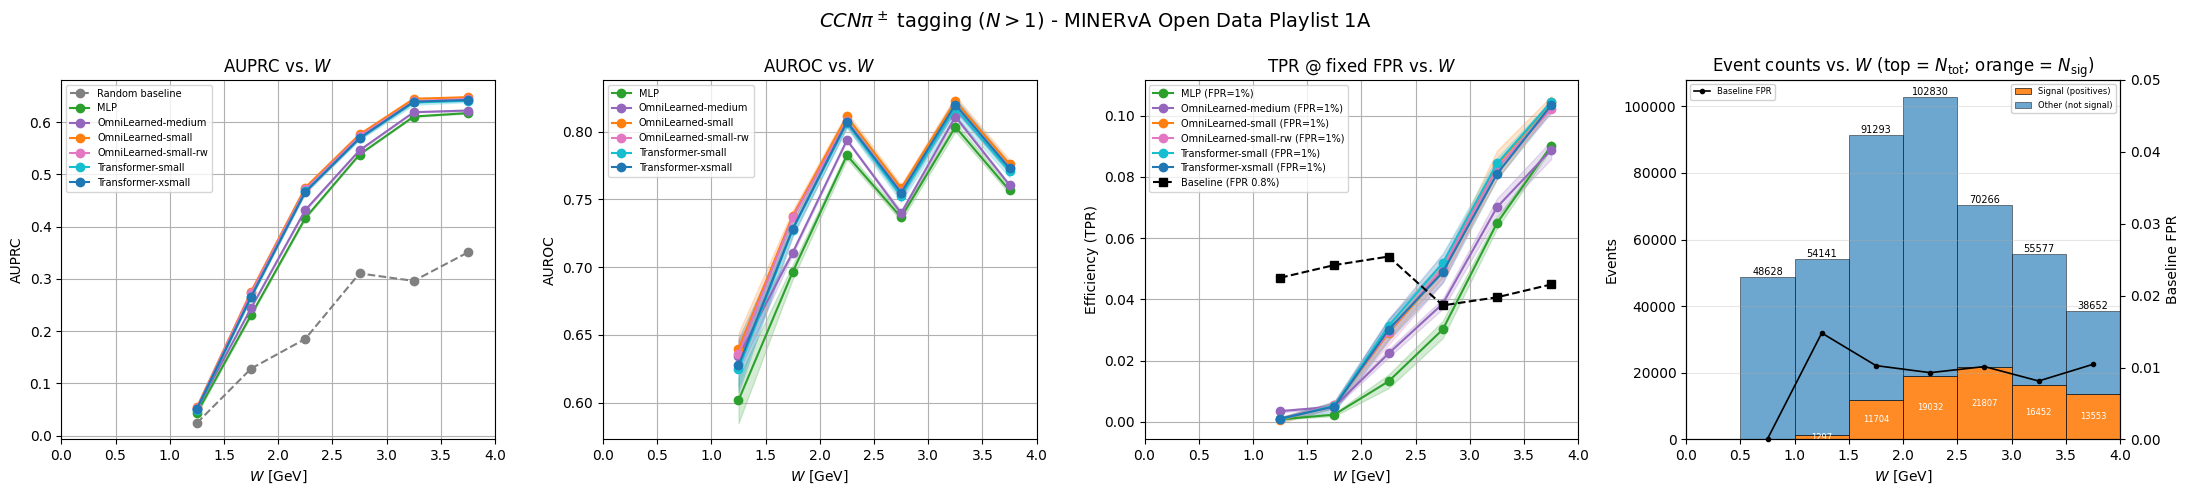

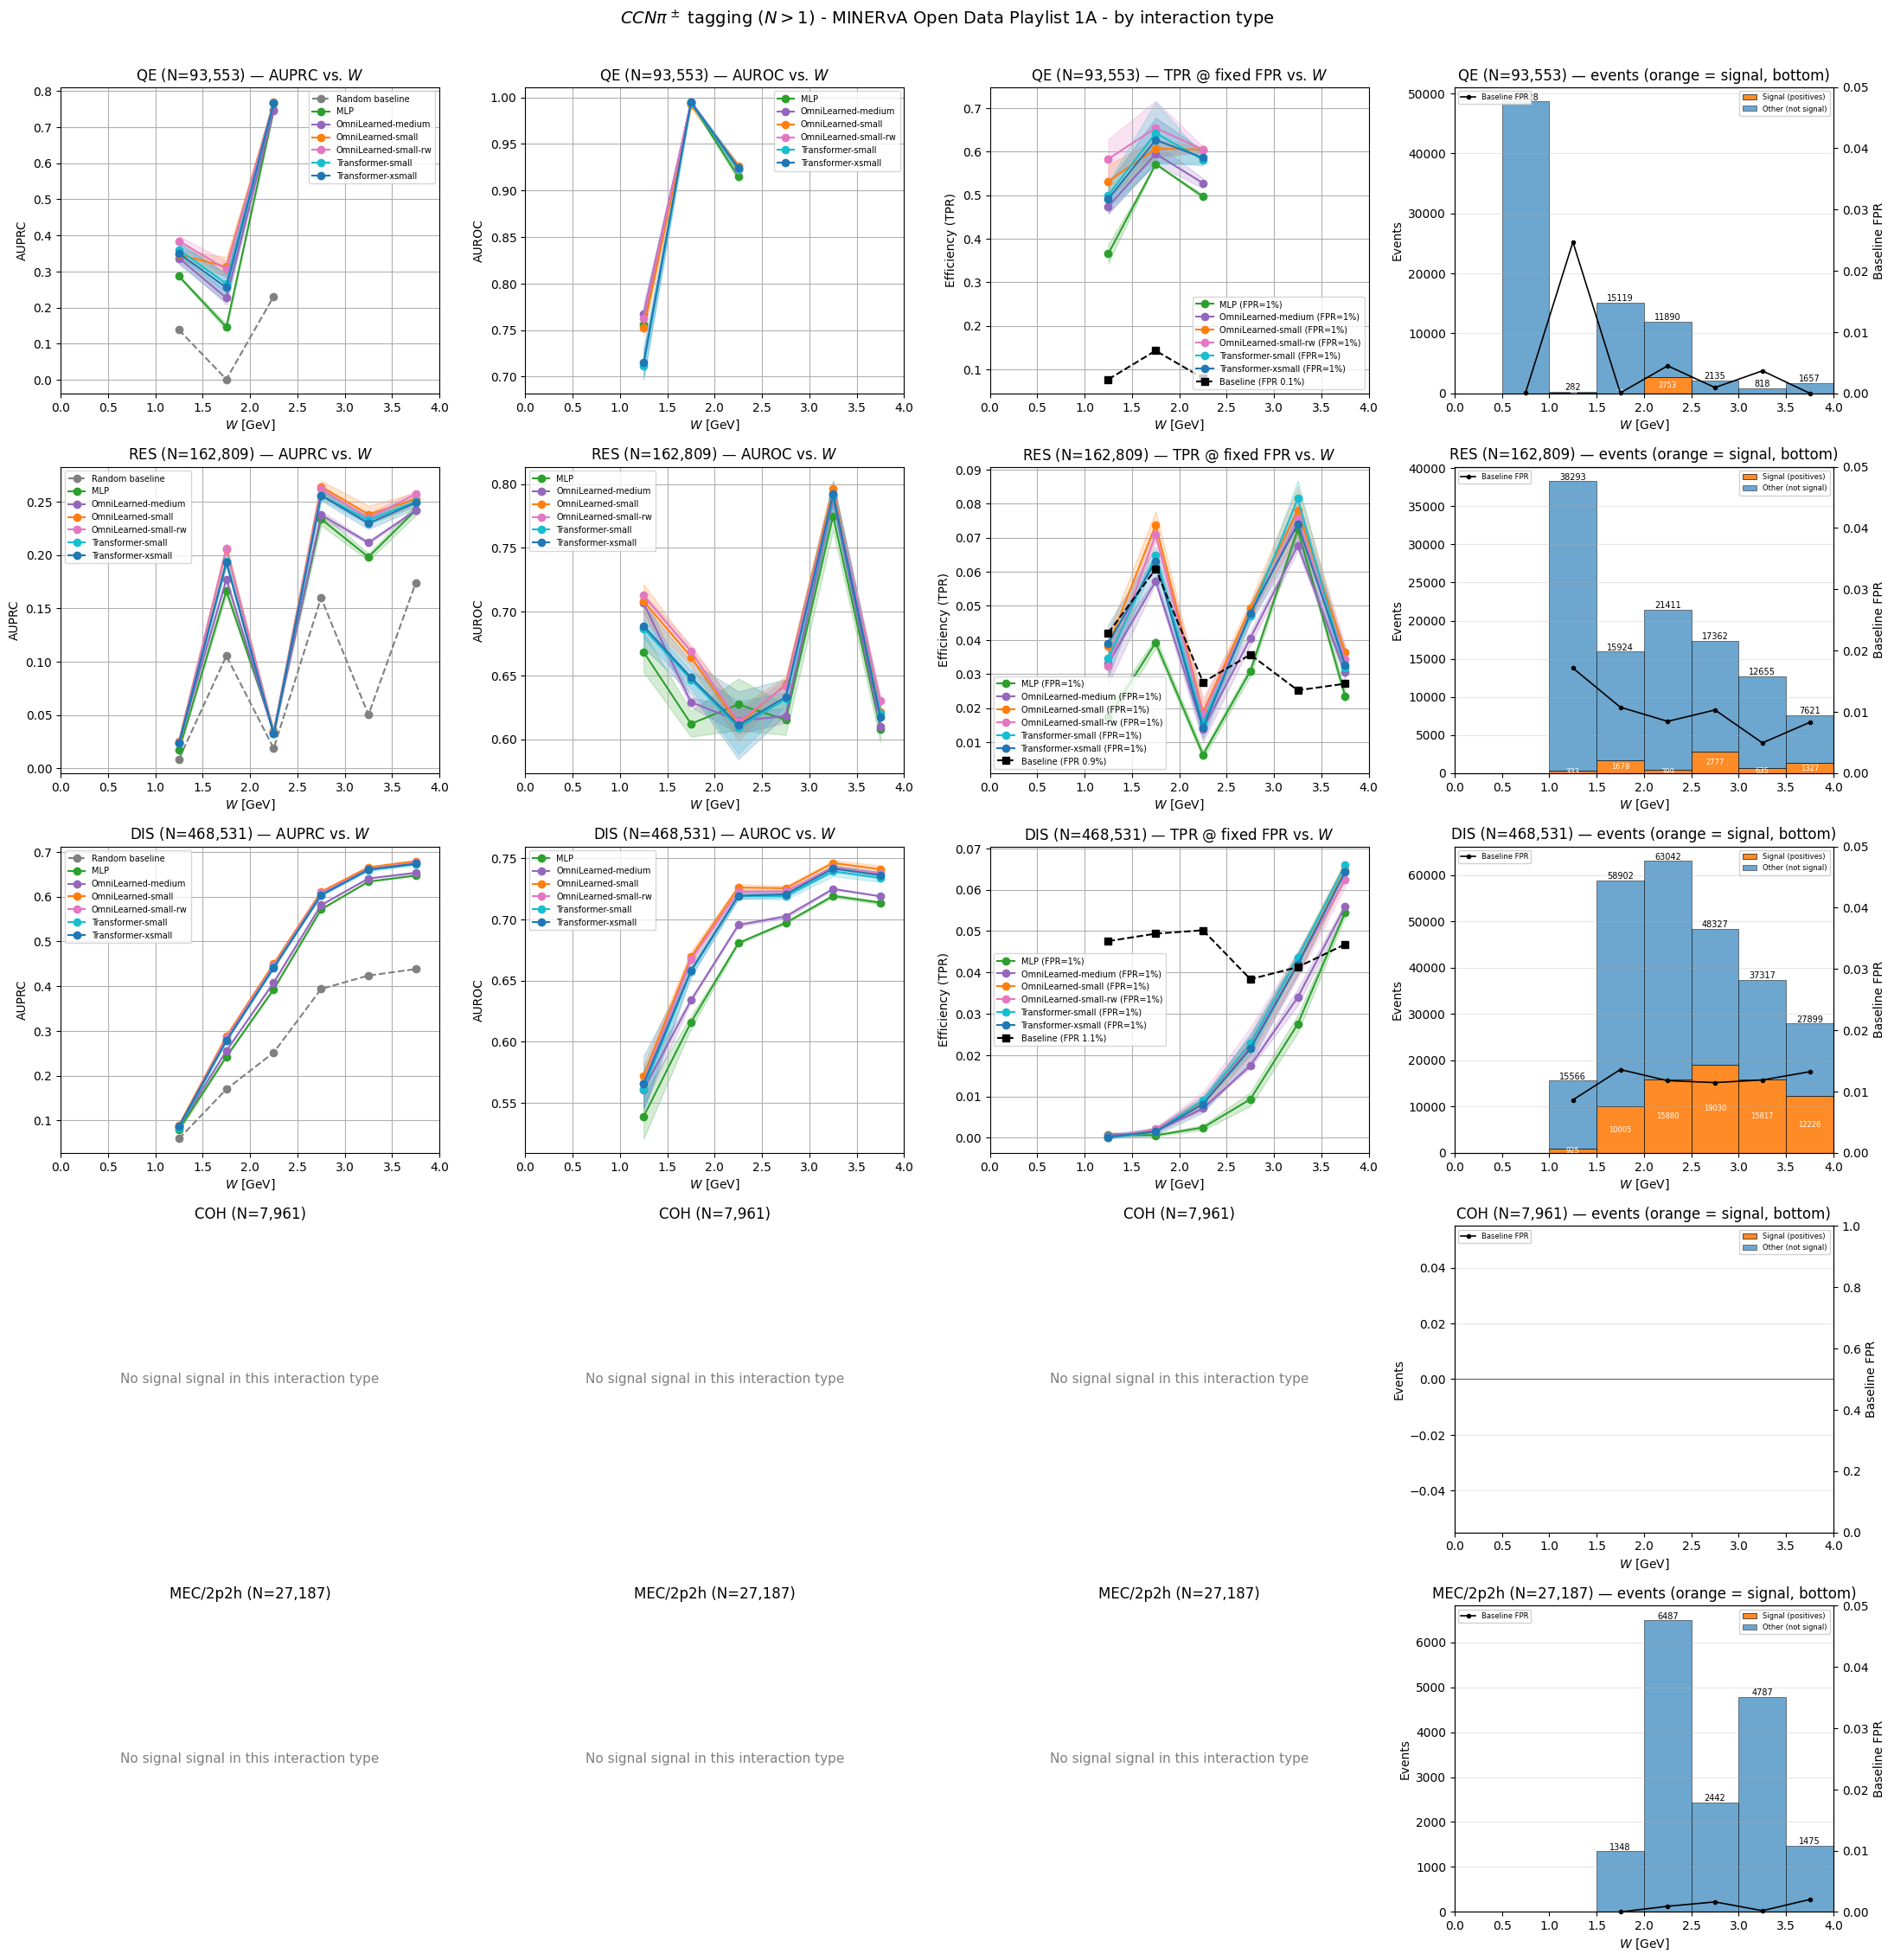

In [ ]:
# CC N > 1 charged pions only (Pi_labels_v2 class 1); reco baseline: >=2 charged-pion prongs + Michel

multi_pi_classes = [1]

for playlist in PLAYLISTS:
    data_w = data_w_by_playlist[playlist]
    figs_npi_W = []

    test_idx = data_w["test_idx"][playlist]
    baselines_pl = data_w["baselines"][playlist]
    n_muons = baselines_pl["n_muons"][test_idx]
    n_charged_prongs = baselines_pl["n_charged_prongs"][test_idx]
    improved_nmichel = baselines_pl["improved_nmichel"][test_idx]
    first_model = next(iter(results))
    run0 = results[first_model][0][playlist]
    pid = run0["pid"]

    y_true_ccnpi = np.isin(pid, multi_pi_classes).astype(int)
    y_pred_ccnpi = (
        (n_muons == 1) & (n_charged_prongs >= 2) & (improved_nmichel >= 1)
    ).astype(int)

    tp = np.sum((y_pred_ccnpi == 1) & (y_true_ccnpi == 1))
    fp = np.sum((y_pred_ccnpi == 1) & (y_true_ccnpi == 0))
    fn = np.sum((y_pred_ccnpi == 0) & (y_true_ccnpi == 1))
    tn = np.sum((y_pred_ccnpi == 0) & (y_true_ccnpi == 0))
    baseline_fpr_ccnpi = fp / (fp + tn)

    metrics_W = compute_all_metrics_W(
        results, data_w, signal_classes=multi_pi_classes, fixed_fpr=[baseline_fpr_ccnpi],
        playlist=playlist,
        use_global_fpr=USE_GLOBAL_FPR,
    )
    baseline_W_multi = compute_signal_baseline_W(
        results, data_w, signal_classes=multi_pi_classes, playlist=playlist,
    )

    is_signal_ccnpi = y_true_ccnpi == 1
    reco_baseline_tpr_W = compute_reco_baseline_recall_per_bin(
        y_pred_ccnpi, is_signal_ccnpi, data_w["W_GeV"], data_w["W_bin_edges"],
    )

    fig = plot_multi_classification_vs_W(
        metrics_W, data_w, baseline_W_multi,
        fixed_fpr=[baseline_fpr_ccnpi], uncertainties=True,
        reco_baseline_tpr_W=reco_baseline_tpr_W,
        reco_baseline_global_fpr=baseline_fpr_ccnpi,
        reco_baseline_pred=y_pred_ccnpi,
        colors=clrs_dict_full,
        title=fr"$CCN\pi^\pm$ tagging ($N > 1$) - MINERvA Open Data Playlist {playlist}",
        use_global_fpr=USE_GLOBAL_FPR,
        playlist=playlist,
        results=results,
        signal_classes=multi_pi_classes,
    )
    figs_npi_W.append(fig)
    fig.show()

    fig = plot_binned_by_inttype(
        results, data_w,
        signal_classes=multi_pi_classes,
        x_var="W",
        xlabel=r"$W$ [GeV]",
        title=fr"$CCN\pi^\pm$ tagging ($N > 1$) - MINERvA Open Data Playlist {playlist} - by interaction type",
        uncertainties=True,
        fixed_fpr=[baseline_fpr_ccnpi],
        reco_baseline_pred=y_pred_ccnpi,
        playlist=playlist,
        colors=clrs_dict_full,
        use_global_fpr=USE_GLOBAL_FPR,
    )
    figs_npi_W.append(fig)
    fig.show()

    save_figures_to_pdf(figs_npi_W, OUTPUT_DIR / f"eval_Npi_Ngt1_tagging_W_{playlist}{_PDF_FPR_TAG}.pdf")
